[-0.76604444  0.64278761]
v1=[1.96961551 0.34729636], v2=[-1.53208889  1.28557522]
theta = tensor([[ 1.9696, -1.5321],
        [ 0.3473,  1.2856]])


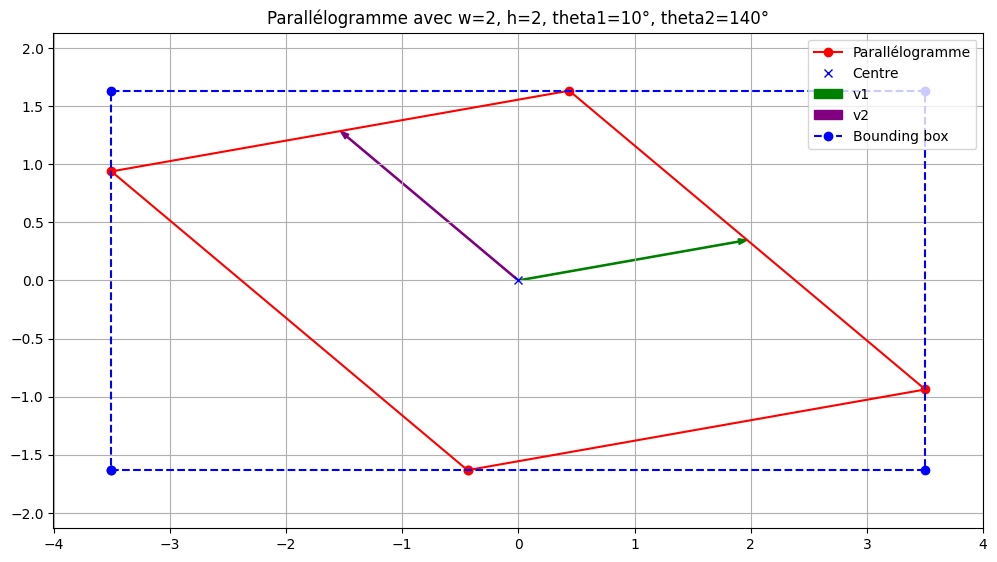

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import torch
def plot_parallelogram(cx, cy, w, h, theta1_deg, theta2_deg):
    """
    Trace un parallélogramme défini par :
      - (cx, cy) : centre géométrique (intersection des diagonales)
      - w, h : longueurs des deux vecteurs
      - theta1_deg, theta2_deg : angles (en degrés) de chaque vecteur
    """
    # Convertir les angles en radians
    theta1 = np.deg2rad(theta1_deg)
    theta2 = np.deg2rad(theta2_deg)

    # Centre
    c = np.array([cx, cy])

    # Vecteurs v1 et v2
    v1 = w * np.array([np.cos(theta1), np.sin(theta1)])
    v2 = h * np.array([np.cos(theta2), np.sin(theta2)])
    print(np.array([np.cos(theta2), np.sin(theta2)]))
    # Calcul des 4 coins du parallélogramme
    # A = centre - 1/2(v1 + v2)
    print(f"v1={v1}, v2={v2}")
    A = c - (v1 + v2)
    B = A + 2*v1
    C = A + 2*(v1 + v2)
    D = A +2* v2


    # Préparation pour l'affichage
    parallelo_x = [A[0], B[0], C[0], D[0], A[0]]
    parallelo_y = [A[1], B[1], C[1], D[1], A[1]]

    plt.figure(figsize=(12, 12))
    plt.plot(parallelo_x, parallelo_y, 'o-r', label="Parallélogramme")

    # Marquer le centre
    plt.plot(cx, cy, 'x', color='blue', label="Centre")

    # Affichage des vecteurs v1, v2 (depuis le centre, pour visualiser)
    # On peut les tracer sous forme de flèches :
    plt.arrow(cx, cy, v1[0], v1[1], 
              width=0.01, color='green', 
              length_includes_head=True, 
              head_width=0.05, label='v1')
    plt.arrow(cx, cy, v2[0], v2[1], 
              width=0.01, color='purple', 
              length_includes_head=True, 
              head_width=0.05, label='v2')

    # Ajuster les limites du graphe
    all_x = parallelo_x + [cx, cx + v1[0], cx + v2[0]]
    all_y = parallelo_y + [cy, cy + v1[1], cy + v2[1]]
    margin = 0.5
    plt.xlim(min(all_x) - margin, max(all_x) + margin)
    plt.ylim(min(all_y) - margin, max(all_y) + margin)


    
    # take min x of v1 and v2
    corners = torch.stack([torch.tensor(A), torch.tensor(B), torch.tensor(C), torch.tensor(D)])
    x_min = corners[..., 0].min(dim=-1).values
    x_max = corners[..., 0].max(dim=-1).values
    y_min = corners[..., 1].min(dim=-1).values
    y_max = corners[..., 1].max(dim=-1).values
    cx_box = 0.5*(x_min + x_max)
    cy_box = 0.5*(y_min + y_max)
    # Width and height of the bounding box
    w_box = x_max - x_min
    h_box = y_max - y_min

    # Plot the bounding box
    plt.plot([x_min, x_max, x_max, x_min, x_min], [y_min, y_min, y_max, y_max, y_min], 'o--b', label="Bounding box")
    # create 2,2 matrix
    theta = torch.zeros( (2,2))
    theta[0,0] = torch.tensor(v1)[0]
    theta[0,1] = torch.tensor(v2)[0]
    theta[1,0] = torch.tensor(v1)[1]
    theta[1,1] = torch.tensor(v2)[1]

    print(f"theta = {theta}")
    # theta = torch.linalg.inv(theta)
    parallelo = torch.stack([torch.tensor(A), torch.tensor(B), torch.tensor(C), torch.tensor(D)])
    # # # #rot parallelo with theta
    # # # parallelo = parallelo - torch.tensor([cx, cy]) 
    # print(f"theta = {theta}")
    # print(parallelo.shape)
    # parallelo = (theta @ parallelo.T.float()).T
    # print(f"parallelo = {parallelo}") 


    # print(parallelo.T.shape)
    # parallelo_x = parallelo[..., 0] 
    # parallelo_y = parallelo[..., 1]
    # plt.plot(parallelo_x, parallelo_y, 'o--g', label="Parallélogramme rotated")

    # theta = torch.linalg.inv(theta)
    # #parallelo = (theta @ parallelo.T.float()).T

    theta_fact = torch.zeros( (2,2))
    theta_fact[0,0] = 1/w_box*2 
    theta_fact[1,1] = 1/h_box*2

    theta = theta_fact @ theta
    parallelo = (theta @ parallelo.T.float()).T
    parallelo_x = parallelo[..., 0]
    parallelo_y = parallelo[..., 1]


    #plt.plot(parallelo_x, parallelo_y, 'o--r', label="Parallélogramme rotated back")
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(f"Parallélogramme avec w={w}, h={h}, "
              f"theta1={theta1_deg}°, theta2={theta2_deg}°")
    plt.legend()
    plt.grid(True)
    plt.show()
    return theta
    




theta =plot_parallelogram(cx=0, cy=0, w=2, h=2, theta1_deg=10, theta2_deg=140)



torch.Size([1, 2, 2]) torch.Size([1, 3, 602, 550])


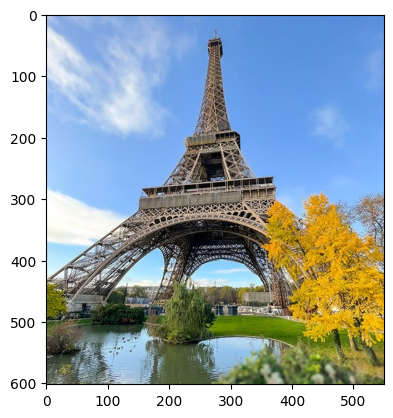

In [70]:
path_img = "/home/rbaena/projects/Temp-DTLR/home-discover-bg.jpg"
# Load the image to pytorch tensor
img_tensor = torch.from_numpy(plt.imread(path_img))
img_tensor = img_tensor.permute(2,0,1)/255
# show the image

theta_f = torch.zeros( (2,3))  
theta_f[0,0] = theta[0,0]
theta_f[0,1] = theta[0,1]
theta_f[1,0] = theta[1,0]
theta_f[1,1] = theta[1,1]

print(theta.unsqueeze(0).shape,img_tensor.unsqueeze(0).size())
grid =F.affine_grid(theta_f.unsqueeze(0), img_tensor.unsqueeze(0).size())
output = F.grid_sample(img_tensor.unsqueeze(0).float(), grid)
ouput = output *255
plt.imshow(output.squeeze(0).permute(1, 2, 0).numpy())
plt.show()


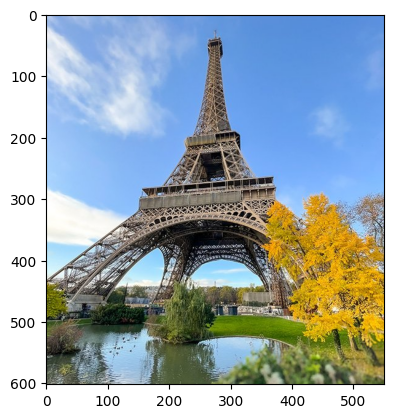

In [53]:
plt.imshow(img_tensor.squeeze(0).permute(1, 2, 0).numpy())
plt.show()


v1=[ 0.70710678 -0.70710678], v2=[0.5       0.8660254]
A=[-0.20710678  0.84108138], B=[ 1.20710678 -0.57313218], C=[2.20710678 1.15891862], D=[0.79289322 2.57313218]


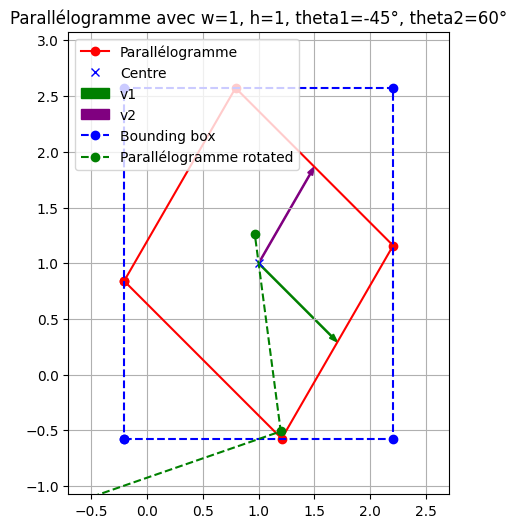

In [66]:
plot_parallelogram(cx=1, cy=1, w=1, h=1, theta1_deg=-45, theta2_deg=60)

v1=[ 0.70710678 -0.70710678], v2=[0.5       0.8660254]
[[ 0.70710678  0.5       ]
 [-0.70710678  0.8660254 ]]


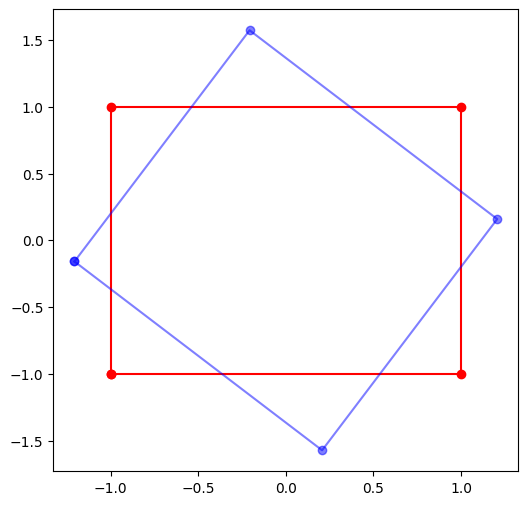

In [ ]:
# def a square of coordinate (-1,-1) , (1,1) , (1,-1), (-1,1)
A = np.array([-1, -1])
B = np.array([1, 1])
C = np.array([1, -1])
D = np.array([-1, 1])
B,C = C,B
parallelo_x = [A[0], B[0], C[0], D[0], A[0]]
parallelo_y = [A[1], B[1], C[1], D[1], A[1]]

plt.figure(figsize=(6, 6))
plt.plot(parallelo_x, parallelo_y, 'o-r', label="Parallélogramme")
theta = np.zeros((2,2))

cx=1 
cy=2 
w=1
h=1 
theta1_deg=-45 
theta2_deg=60
theta1 = np.deg2rad(theta1_deg)
theta2 = np.deg2rad(theta2_deg)

# Centre
c = np.array([cx, cy])

# Vecteurs v1 et v2
v1 = w * np.array([np.cos(theta1), np.sin(theta1)])
v2 = h * np.array([np.cos(theta2), np.sin(theta2)])
print(f"v1={v1}, v2={v2}")
theta[0,0] = v1[0]
theta[0,1] = v2[0]
theta[1,0] = v1[1]
theta[1,1] = v2[1]
print(theta)
A_rot = np.dot(theta, A)
B_rot = np.dot(theta, B)
C_rot = np.dot(theta, C)
D_rot = np.dot(theta, D)

parallelo_x = [A_rot[0], B_rot[0], C_rot[0], D_rot[0], A_rot[0]]
parallelo_y = [A_rot[1], B_rot[1], C_rot[1], D_rot[1], A_rot[1]]
plt.plot(parallelo_x, parallelo_y, 'o-b', label="Parallélogramme", alpha=0.5)

In [48]:
theta

array([[0., 0.],
       [0., 0.]])

In [11]:
import torch
import torch.nn.functional as F

# Example theta (batch of affine transformations, 2x3)
# Identity transformation for batch size 1
theta = torch.tensor([[[2, 0, 0], 
                       [0, 2, 0]]], dtype=torch.float)  # Shape: (1, 2, 3)

# Define the size of the output grid
# Example: Batch size 1, 1 channel, 5x5 grid
size = (1, 1, 5, 5)

# Generate the grid
grid = F.affine_grid(theta, size, align_corners=False)

# Print the generated grid
print(grid)

tensor([[[[-1.6000, -1.6000],
          [-0.8000, -1.6000],
          [ 0.0000, -1.6000],
          [ 0.8000, -1.6000],
          [ 1.6000, -1.6000]],

         [[-1.6000, -0.8000],
          [-0.8000, -0.8000],
          [ 0.0000, -0.8000],
          [ 0.8000, -0.8000],
          [ 1.6000, -0.8000]],

         [[-1.6000,  0.0000],
          [-0.8000,  0.0000],
          [ 0.0000,  0.0000],
          [ 0.8000,  0.0000],
          [ 1.6000,  0.0000]],

         [[-1.6000,  0.8000],
          [-0.8000,  0.8000],
          [ 0.0000,  0.8000],
          [ 0.8000,  0.8000],
          [ 1.6000,  0.8000]],

         [[-1.6000,  1.6000],
          [-0.8000,  1.6000],
          [ 0.0000,  1.6000],
          [ 0.8000,  1.6000],
          [ 1.6000,  1.6000]]]])


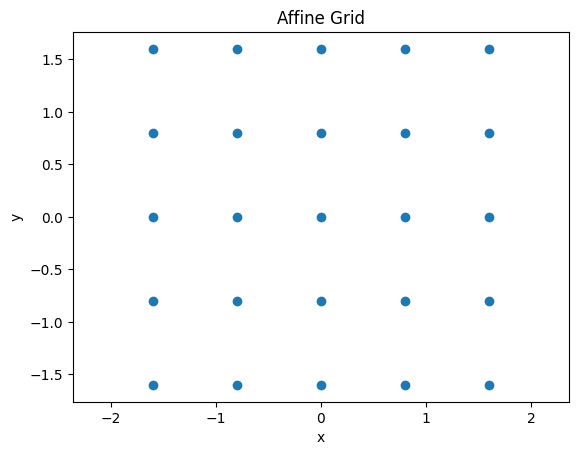

In [12]:
import matplotlib.pyplot as plt

# Reshape the grid for visualization (H * W, 2)
grid_reshaped = grid[0].view(-1, 2).detach().numpy()

# Plot the grid
plt.scatter(grid_reshaped[:, 0], grid_reshaped[:, 1])
plt.title("Affine Grid")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.show()